# 00 — DualPath Pipeline: Vehicle Detection + Geometric Lane Prediction

**Architecture: DualPathNet**
- Shared ResNet-50 + FPN backbone
- RT-DETR-inspired transformer detection decoder (vehicle-only)
- MapTR-inspired query-based lane decoder (structured polylines, NOT masks)
- Optional weak cross-branch attention

**Dataset: BDD100K**
- Detection: YOLO-format labels, vehicle classes only
- Lanes: structured targets from original BDD100K poly2d annotations

**Key design choices:**
- Weakly-coupled dual-path reduces negative transfer between tasks
- Lane prediction is geometric (ordered point sequences), not raster masks
- Architecture is future-ready for temporal lane memory (StreamMapNet-style)

## 1 — Environment Setup

In [1]:
!pip install -q torch torchvision torchmetrics pyyaml scipy opencv-python matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 18.0 MB/s eta 0:00:00


In [2]:
import torch
import os, sys

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
    mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {gpu} ({mem:.1f} GB)")
else:
    print("WARNING: No GPU — training will be slow")

GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition (102.0 GB)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# ── Fixed Drive paths (preserved from old pipeline) ──
ECOCAR_ROOT = "/content/drive/MyDrive/EcoCAR"
DATASET_DRIVE = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo")
WEIGHTS_DIR = os.path.join(ECOCAR_ROOT, "weights")
TRAINING_RUNS = os.path.join(ECOCAR_ROOT, "training_runs")

# ── Project code ──
PROJECT_DIR = os.path.join(ECOCAR_ROOT, "DETR_GeoLane_pipeline")
if not os.path.isdir(PROJECT_DIR):
    # Fallback: clone from repo
    !git clone https://github.com/ChenSiyun1234/EcoCAR-Perception-Pipeline-BDD100K.git /content/repo 2>/dev/null || true
    PROJECT_DIR = "/content/repo/DETR_GeoLane_pipeline"

sys.path.insert(0, PROJECT_DIR)
print(f"Project: {PROJECT_DIR}")
print(f"Dataset: {DATASET_DRIVE}")

Mounted at /content/drive
Project: /content/drive/MyDrive/EcoCAR/DETR_GeoLane_pipeline
Dataset: /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo


## 2 — Dataset Inspection

Reuses the existing BDD100K YOLO-format dataset from the old pipeline.
Detection labels are `.txt` files; lane targets are parsed from raw BDD100K JSON.

In [4]:
import tarfile

LOCAL_DS = "/content/bdd100k_yolo"
os.makedirs(LOCAL_DS, exist_ok=True)

# Extract from Drive tar if needed (faster than FUSE)
NB02_TAR = os.path.join(ECOCAR_ROOT, "datasets", "bdd100k_yolo_nb02.tar")
if not os.path.isdir(os.path.join(LOCAL_DS, "images", "val")):
    if os.path.isfile(NB02_TAR):
        print(f"Extracting {NB02_TAR} ...")
        with tarfile.open(NB02_TAR, "r") as tar:
            tar.extractall(LOCAL_DS, filter='data')
        print("Done.")
    elif os.path.isdir(os.path.join(DATASET_DRIVE, "images")):
        # Symlink from Drive
        for sub in ["images", "labels"]:
            src = os.path.join(DATASET_DRIVE, sub)
            dst = os.path.join(LOCAL_DS, sub)
            if not os.path.exists(dst) and os.path.isdir(src):
                os.symlink(src, dst)
        print("Linked dataset from Drive.")
    else:
        print(f"ERROR: No dataset found at {NB02_TAR} or {DATASET_DRIVE}")

# Count
for split in ["train", "val"]:
    img_dir = os.path.join(LOCAL_DS, "images", split)
    lbl_dir = os.path.join(LOCAL_DS, "labels", split)
    n_img = len(os.listdir(img_dir)) if os.path.isdir(img_dir) else 0
    n_lbl = len(os.listdir(lbl_dir)) if os.path.isdir(lbl_dir) else 0
    print(f"  {split}: {n_img} images, {n_lbl} labels")

Extracting /content/drive/MyDrive/EcoCAR/datasets/bdd100k_yolo_nb02.tar ...
Done.
  train: 70000 images, 70000 labels
  val: 10000 images, 10000 labels


In [5]:
# ── Detection class distribution ──
from collections import Counter

from src.config import BDD_TO_VEHICLE, VEHICLE_CLASSES

lbl_dir = os.path.join(LOCAL_DS, "labels", "train")
class_counts = Counter()
total_files = 0

if os.path.isdir(lbl_dir):
    for f in os.listdir(lbl_dir):
        if not f.endswith(".txt"):
            continue
        total_files += 1
        with open(os.path.join(lbl_dir, f)) as fh:
            for line in fh:
                cls_id = int(line.strip().split()[0])
                if cls_id in BDD_TO_VEHICLE:
                    class_counts[BDD_TO_VEHICLE[cls_id]] += 1

print(f"Vehicle detection class distribution ({total_files} files):")
for i, name in enumerate(VEHICLE_CLASSES):
    print(f"  {name:<12}: {class_counts.get(i, 0):>8,}")
print(f"  Total vehicles: {sum(class_counts.values()):>8,}")

Vehicle detection class distribution (70000 files):
  car         :  714,121
  truck       :   30,012
  bus         :   11,688
  motorcycle  :        0
  bicycle     :        0
  Total vehicles:  755,821


## 3 — Lane Annotation Parsing

Parse raw BDD100K poly2d annotations into structured lane targets.
Each lane becomes a fixed-length ordered point sequence (72 points).

In [6]:
from src.config import lane_search_debug
import json, os

for split in ["train", "val"]:
    dbg = lane_search_debug(split)
    print(f"[{split}] zip candidates tried:")
    for p in dbg["zip_candidates"]:
        print(f"  {p}")
    print(f"raw_root: {dbg['raw_root']}")
    print()
    print(f"[{split}] candidates:")
    for p in dbg["candidates"]:
        mark = "*" if p == dbg["chosen"] else " "
        print(f"  {p} {mark}")
    print()
    print(f"chosen {split} source: {dbg['chosen']}")
    print(f"chosen_is_dir: {dbg['chosen_is_dir']}")
    print()

train_lane_json = lane_search_debug("train")["chosen"]
val_lane_json = lane_search_debug("val")["chosen"]

def preview_source(src):
    if not src:
        print("No source chosen")
        return
    if os.path.isdir(src):
        files = sorted([f for f in os.listdir(src) if f.endswith(".json")])
        print("dir json count:", len(files))
        if not files:
            return
        sample = os.path.join(src, files[0])
        print("sample json:", sample)
        with open(sample, "r") as f:
            data = json.load(f)
        print("sample top-level type:", type(data))
        if isinstance(data, dict):
            print("sample keys:", list(data.keys())[:20])
            if "labels" in data:
                labels = data.get("labels", [])
                print("labels type:", type(labels), "count:", len(labels))
                if labels:
                    print("first label keys:", list(labels[0].keys()))
                    print("first label category:", labels[0].get("category"))
                    print("has poly2d:", "poly2d" in labels[0])
            if "frames" in data:
                frames = data.get("frames", [])
                print("frames type:", type(frames), "count:", len(frames))
                if frames:
                    print("first frame keys:", list(frames[0].keys()))
        elif isinstance(data, list):
            print("list len:", len(data))
            if data and isinstance(data[0], dict):
                print("first item keys:", list(data[0].keys()))
    elif os.path.isfile(src):
        with open(src, "r") as f:
            data = json.load(f)
        print("file top-level type:", type(data), "len:", len(data) if hasattr(data, "__len__") else "n/a")
        if isinstance(data, list) and data:
            print("first item keys:", list(data[0].keys()))

print("=== train preview ===")
preview_source(train_lane_json)


[train] zip candidates tried:
  /content/drive/MyDrive/EcoCAR/downloads/bdd100k_labels.zip
raw_root: /content/bdd100k_labels_unzipped

[train] candidates:
  /content/bdd100k_labels_unzipped/100k/train *
  /content/bdd100k_labels_unzipped/bdd100k/100k/train  
  /content/bdd100k_labels_unzipped/bdd100k/labels/bdd100k_labels_images_train.json  
  /content/bdd100k_labels_unzipped/labels/bdd100k_labels_images_train.json  
  /content/bdd100k_labels_unzipped/bdd100k/labels/lane/polygons/lane_train.json  
  /content/bdd100k_labels_unzipped/labels/lane/polygons/lane_train.json  

chosen train source: /content/bdd100k_labels_unzipped/100k/train
chosen_is_dir: True

[val] zip candidates tried:
  /content/drive/MyDrive/EcoCAR/downloads/bdd100k_labels.zip
raw_root: /content/bdd100k_labels_unzipped

[val] candidates:
  /content/bdd100k_labels_unzipped/100k/val *
  /content/bdd100k_labels_unzipped/bdd100k/100k/val  
  /content/bdd100k_labels_unzipped/bdd100k/labels/bdd100k_labels_images_val.json  
  

In [7]:
# Inspect real per-image JSON structure and find an example object with poly2d
if train_lane_json and os.path.isdir(train_lane_json):
    import json, os
    files = sorted([os.path.join(train_lane_json, x) for x in os.listdir(train_lane_json) if x.endswith('.json')])
    print('dir json count:', len(files))
    sample_json = files[0]
    print('sample json:', sample_json)
    with open(sample_json, 'r') as f:
        sample = json.load(f)
    print('sample top-level type:', type(sample))
    print('sample keys:', list(sample.keys()) if isinstance(sample, dict) else 'N/A')
    frames = sample.get('frames', []) if isinstance(sample, dict) else []
    print('frames type:', type(frames), 'count:', len(frames) if isinstance(frames, list) else 'N/A')
    if frames:
        print('first frame keys:', list(frames[0].keys()))
    found = None
    found_file = None
    for fp in files[:200]:
        with open(fp, 'r') as f:
            rec = json.load(f)
        frs = rec.get('frames', []) if isinstance(rec, dict) else []
        if not frs:
            continue
        objs = frs[0].get('objects', [])
        for obj in objs:
            if isinstance(obj, dict) and 'poly2d' in obj:
                found = obj
                found_file = fp
                break
        if found is not None:
            break
    print('found poly2d in:', found_file)
    if found is not None:
        print('poly2d object keys:', list(found.keys()))
        print('poly2d category:', found.get('category'))
        print('poly2d attributes:', found.get('attributes'))
        print('poly2d field type:', type(found.get('poly2d')))


lane_src = /content/bdd100k_labels_unzipped/100k/train
sample json = /content/bdd100k_labels_unzipped/100k/train/0000f77c-6257be58.json
top-level type = <class 'dict'>
top-level keys = ['name', 'frames', 'attributes']
first frame keys = ['timestamp', 'objects']
first object keys = ['category', 'id', 'attributes', 'box2d']
first object category = traffic light
first object attributes = {'occluded': False, 'truncated': False, 'trafficLightColor': 'green'}
first object has poly2d = False


Loading lane labels from directory /content/bdd100k_labels_unzipped/100k/train ...
  Cached lane labels for 66640 frames
Frames with lane annotations: 66640

Sample: 0000f77c-6257be58 — 0 lanes


/tmp/ipykernel_3364/696093710.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


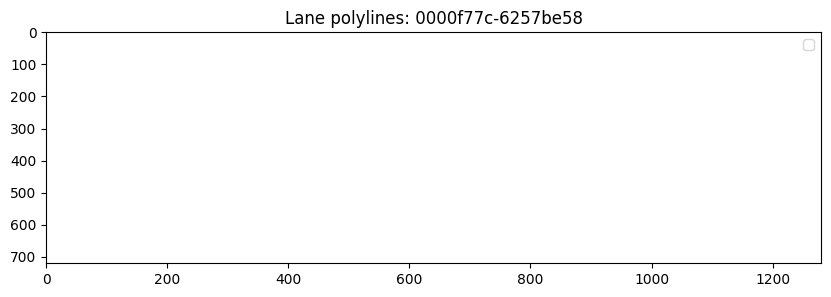

In [8]:
# Preview a non-empty lane sample overlaid on the real image
if train_lane_json:
    from src.lane_targets import LaneLabelCache
    from pathlib import Path
    import matplotlib.pyplot as plt
    import cv2

    cache = LaneLabelCache(train_lane_json, max_lanes=10, num_points=72)
    print(f"Frames with usable lane annotations: {len(cache)}")

    sample_name = None
    sample_targets = None
    for name in cache._cache.keys():
        t = cache.get(name)
        if t is not None and int(t["existence"].sum()) > 0:
            sample_name = name
            sample_targets = t
            break

    if sample_name is None:
        print("No non-empty trainable lane sample found.")
    else:
        n_lanes = int(sample_targets["existence"].sum())
        print(f"Sample: {sample_name} — {n_lanes} lanes")
        img_path = Path(cfg.dataset_root) / "images" / "train" / sample_name
        print("image path:", img_path)
        img = None
        if img_path.exists():
            tmp = cv2.imread(str(img_path))
            if tmp is not None:
                img = cv2.cvtColor(tmp, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(figsize=(14, 6))
        if img is not None:
            ax.imshow(img)
        for i in range(n_lanes):
            pts = sample_targets["points"][i]
            vis = sample_targets["visibility"][i] > 0
            if vis.sum() < 2:
                continue
            ax.plot(pts[vis, 0] * 1280, pts[vis, 1] * 720, '-', linewidth=2, label=f"Lane {i}")
        ax.set_xlim(0, 1280)
        ax.set_ylim(720, 0)
        ax.set_title(f"Lane polylines overlay: {sample_name}")
        ax.legend()
        plt.show()


Loading lane labels from directory /content/bdd100k_labels_unzipped/100k/train ...
  Cached lane labels for 66640 frames
Frames with lane annotations: 66640

Sample: 0000f77c-6257be58 — 0 lanes


/tmp/ipykernel_3364/1619729892.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


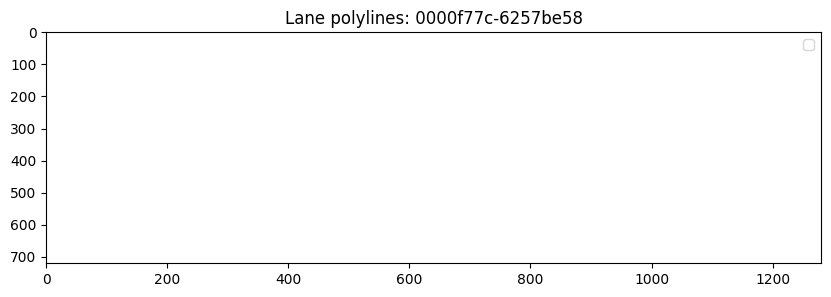

In [9]:
# Preview a non-empty lane sample overlaid on the real image
if train_lane_json:
    from src.lane_targets import LaneLabelCache
    from pathlib import Path
    import matplotlib.pyplot as plt
    import cv2

    cache = LaneLabelCache(train_lane_json, max_lanes=10, num_points=72)
    print(f"Frames with usable lane annotations: {len(cache)}")

    sample_name = None
    sample_targets = None
    for name in cache._cache.keys():
        t = cache.get(name)
        if t is not None and int(t["existence"].sum()) > 0:
            sample_name = name
            sample_targets = t
            break

    if sample_name is None:
        print("No non-empty trainable lane sample found.")
    else:
        n_lanes = int(sample_targets["existence"].sum())
        print(f"Sample: {sample_name} — {n_lanes} lanes")
        img_path = Path(cfg.dataset_root) / "images" / "train" / sample_name
        print("image path:", img_path)
        img = None
        if img_path.exists():
            tmp = cv2.imread(str(img_path))
            if tmp is not None:
                img = cv2.cvtColor(tmp, cv2.COLOR_BGR2RGB)

        fig, ax = plt.subplots(figsize=(14, 6))
        if img is not None:
            ax.imshow(img)
        for i in range(n_lanes):
            pts = sample_targets["points"][i]
            vis = sample_targets["visibility"][i] > 0
            if vis.sum() < 2:
                continue
            ax.plot(pts[vis, 0] * 1280, pts[vis, 1] * 720, '-', linewidth=2, label=f"Lane {i}")
        ax.set_xlim(0, 1280)
        ax.set_ylim(720, 0)
        ax.set_title(f"Lane polylines overlay: {sample_name}")
        ax.legend()
        plt.show()


## 4 — Configuration

In [10]:
from src.config import Config

cfg = Config(
    run_name="dualpath_v1",
    dataset_root=LOCAL_DS,
    img_size=640,
    batch_size=8,
    backbone="resnet50",
    pretrained=True,
    det_num_queries=100,
    det_dec_layers=3,
    lane_num_queries=10,
    lane_dec_layers=3,
    lane_points=72,
    cross_attn=True,
    epochs=50,
    lr=1e-4,
    patience=15,
)

cfg.save(os.path.join(cfg.save_dir, "config.yaml"))
print(f"Config saved to {cfg.save_dir}")
print(f"  Backbone: {cfg.backbone}")
print(f"  Det queries: {cfg.det_num_queries}")
print(f"  Lane queries: {cfg.lane_num_queries} x {cfg.lane_points} points")
print(f"  Cross-attn: {cfg.cross_attn}")

Config saved to /content/drive/MyDrive/EcoCAR/training_runs/dualpath_v1
  Backbone: resnet50
  Det queries: 100
  Lane queries: 10 x 72 points
  Cross-attn: True


## 5 — Build Model

In [11]:
from src.model import build_model

model = build_model(cfg)
model.print_summary()

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s]


DualPathNet summary:
  Backbone+FPN :   26,196,544
  Det encoder  :      789,760
  Det decoder  :    3,320,074
  Lane encoder :      789,760
  Lane decoder :    3,352,032
  Cross-attn   :      527,360
  Total        :   34,975,530
  Det queries=100, Lane queries=10, Lane points=72


In [12]:
# Sanity check forward pass
dummy = torch.randn(2, 3, cfg.img_size, cfg.img_size)
if torch.cuda.is_available():
    dummy = dummy.cuda()
    model = model.cuda()

with torch.no_grad():
    out = model(dummy)

for k, v in out.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: {v.shape}")

model = model.cpu()
torch.cuda.empty_cache()

  det_pred_logits: torch.Size([2, 100, 6])
  det_pred_boxes: torch.Size([2, 100, 4])
  det_query_features: torch.Size([2, 100, 256])
  lane_exist_logits: torch.Size([2, 10, 1])
  lane_pred_points: torch.Size([2, 10, 72, 2])
  lane_vis_logits: torch.Size([2, 10, 72])
  lane_type_logits: torch.Size([2, 10, 7])
  lane_query_features: torch.Size([2, 10, 256])


## 6 — Dataset & DataLoader

In [13]:
from src.dataset import build_dataloaders

train_loader, val_loader = build_dataloaders(
    cfg,
    train_lane_json=train_lane_json,
    val_lane_json=val_lane_json,
)

print(f"Train: {len(train_loader.dataset)} samples, {len(train_loader)} batches")
print(f"Val:   {len(val_loader.dataset)} samples, {len(val_loader)} batches")

Loading lane labels from directory /content/bdd100k_labels_unzipped/100k/train ...
  Cached lane labels for 66640 frames
Loading lane labels from directory /content/bdd100k_labels_unzipped/100k/val ...
  Cached lane labels for 9526 frames
  Dataset: 70000 images from /content/bdd100k_yolo/images/train
  Dataset: 10000 images from /content/bdd100k_yolo/images/val
Train: 70000 samples, 8750 batches
Val:   10000 samples, 1250 batches


Images: torch.Size([8, 3, 640, 640])
Det targets: torch.Size([71, 6])
Lane existence: torch.Size([8, 10])
Lane points: torch.Size([8, 10, 72, 2])
Has lanes: tensor([0., 0., 0., 0., 0., 0., 0., 0.])


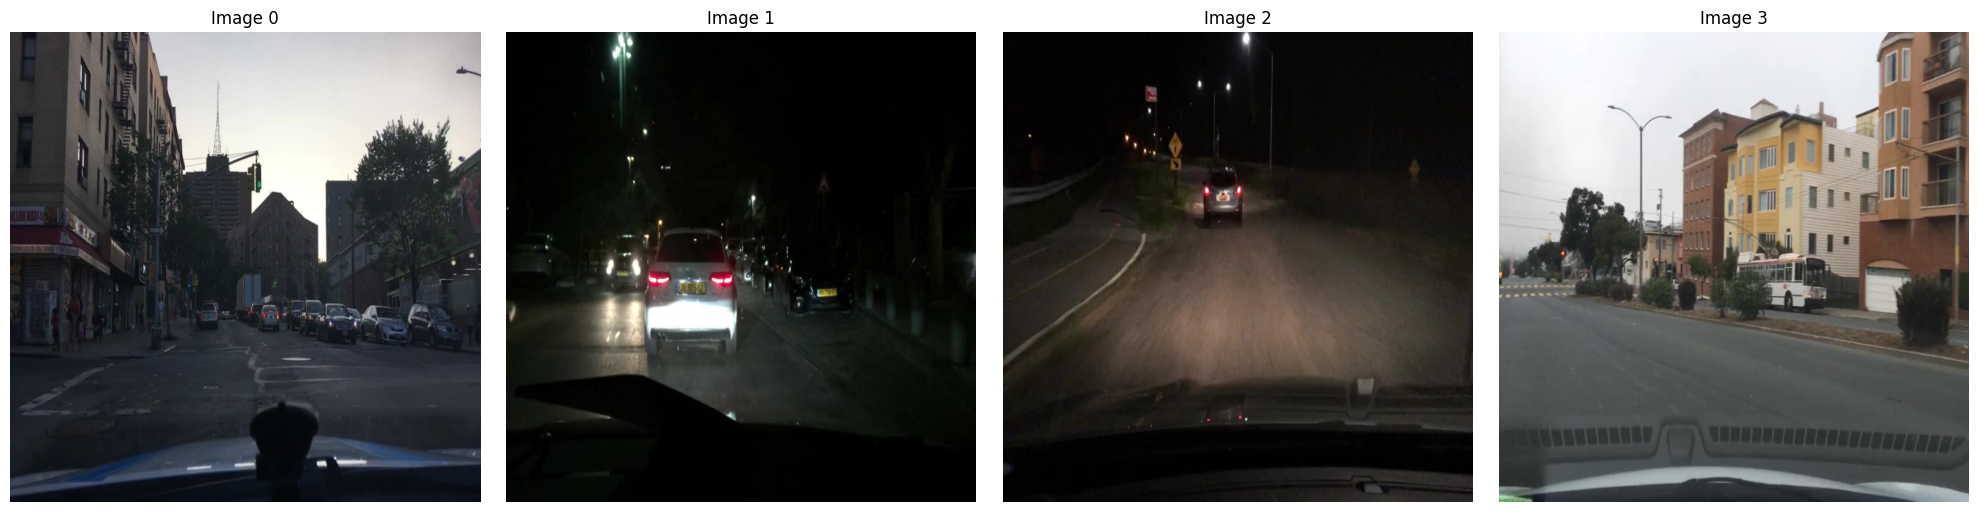

In [14]:
# Visualize a batch
import matplotlib.pyplot as plt
import numpy as np

batch = next(iter(train_loader))
print(f"Images: {batch['images'].shape}")
print(f"Det targets: {batch['det_targets'].shape}")
print(f"Lane existence: {batch['lane_existence'].shape}")
print(f"Lane points: {batch['lane_points'].shape}")
print(f"Has lanes: {batch['has_lanes']}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(min(4, batch['images'].shape[0])):
    img = batch['images'][i].permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Image {i}")
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 7 — Training

Trains the DualPathNet with:
- AdamW optimizer (backbone LR x0.1)
- Cosine LR schedule with warmup
- Hungarian matching for both detection and lane tasks
- Metric-driven checkpointing (best det, best lane, best joint)

In [15]:
from src.trainer import Trainer

trainer = Trainer(cfg, model, train_loader, val_loader)
print(f"Training for {cfg.epochs} epochs")
print(f"Save dir: {cfg.save_dir}")

Training for 50 epochs
Save dir: /content/drive/MyDrive/EcoCAR/training_runs/dualpath_v1


In [ ]:
import traceback

try:
    history = trainer.train()
except Exception as e:
    print(f"\nTraining stopped: {e}")
    traceback.print_exc(limit=5)
    history = trainer.history

print(f"\nLogged {len(history)} epochs.")


  DualPathNet Training: 50 epochs
  Classes: car, truck, bus, motorcycle, bicycle
  Save: /content/drive/MyDrive/EcoCAR/training_runs/dualpath_v1


## 8 — Training Curves

In [ ]:
import matplotlib.pyplot as plt

if history and len(history) > 0:
    epochs = range(1, len(history) + 1)
    train_loss = [h.get("train_loss", 0) for h in history]
    val_loss = [h.get("val_loss", 0) for h in history]
    det_map = [h.get("det_map50", 0) * 100 for h in history]
    lane_f1 = [h.get("lane_f1", 0) * 100 for h in history]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].plot(epochs, train_loss, label="Train")
    axes[0].plot(epochs, val_loss, label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs, det_map)
    axes[1].set_title("Detection mAP@50 (%)")
    axes[1].set_xlabel("Epoch")

    axes[2].plot(epochs, lane_f1)
    axes[2].set_title("Lane F1 (%)")
    axes[2].set_xlabel("Epoch")

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.save_dir, "training_curves.png"), dpi=150)
    plt.show()
else:
    print("No history to plot.")

## 9 — Qualitative Inference

In [ ]:
import cv2
import random
from src.visualize import draw_all

model.eval()
if torch.cuda.is_available():
    model = model.cuda()

val_dir = os.path.join(LOCAL_DS, "images", "val")
all_images = sorted(os.listdir(val_dir))
random.seed(42)
sample_images = random.sample(all_images, min(6, len(all_images)))

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, fname in enumerate(sample_images):
    img_bgr = cv2.imread(os.path.join(val_dir, fname))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (cfg.img_size, cfg.img_size))

    tensor = torch.from_numpy(img_resized.astype(np.float32) / 255.0).permute(2, 0, 1)
    tensor = tensor.unsqueeze(0).to(next(model.parameters()).device)

    with torch.no_grad(), torch.amp.autocast("cuda", enabled=cfg.amp):
        outputs = model(tensor)

    vis = draw_all(img_resized, outputs, conf_thresh=0.3, lane_thresh=0.5)

    ax = axes[i // 3, i % 3]
    ax.imshow(vis)
    ax.set_title(fname)
    ax.axis('off')

plt.suptitle("DualPathNet Inference", fontsize=14)
plt.tight_layout()
plt.show()

## 10 — Export Best Weights

In [ ]:
import shutil

best_src = os.path.join(cfg.save_dir, "weights", "best_joint.pt")
best_dst = os.path.join(WEIGHTS_DIR, f"{cfg.run_name}_best.pt")

os.makedirs(WEIGHTS_DIR, exist_ok=True)

if os.path.isfile(best_src):
    shutil.copy2(best_src, best_dst)
    print(f"Best weights copied to: {best_dst}")
else:
    last_src = os.path.join(cfg.save_dir, "weights", "last.pt")
    if os.path.isfile(last_src):
        last_dst = os.path.join(WEIGHTS_DIR, f"{cfg.run_name}_last.pt")
        shutil.copy2(last_src, last_dst)
        print(f"Last weights copied to: {last_dst}")

print("\n" + "="*55)
print("  TRAINING COMPLETE")
print("="*55)
print(f"  Run:        {cfg.run_name}")
print(f"  Epochs:     {len(history)}")
print(f"  Best det:   {trainer.best_scores['det']*100:.2f}%")
print(f"  Best lane:  {trainer.best_scores['lane']*100:.2f}%")
print(f"  Best joint: {trainer.best_scores['joint']:.4f}")
print(f"  Weights:    {WEIGHTS_DIR}")
print("="*55)